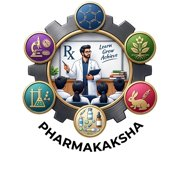

# BP604T · Unit IV — AI in Process Monitoring and Production
**Pharmakaksha · Learn · Grow · Achieve**
*AI applications in Pharmaceutical Sciences · B.Pharm Semester VI · PCI NEP 2020*

This notebook contains every example and demo from the Unit IV study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit4_AI_in_Process_Monitoring.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit4_AI_in_Process_Monitoring.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. Real drug names and structures are used only to show how the methods work. The models are for learning AI methods only. They are not quality-control, regulatory or clinical tools.

## 4.1 Digital data acquisition
Modern plants record process data automatically: sensors and **PAT** tools (process analytical technology, such as an in-line NIR probe), the equipment's control system (PLC/SCADA), a **data historian**, and electronic batch records. GMP data must be **ALCOA+**: Attributable, Legible, Contemporaneous, Original, Accurate, plus Complete, Consistent, Enduring and Available.

`fbd_drying.csv` is one fictional fluid-bed drying run, logged once a minute. The NIR probe measures moisture (loss on drying, LOD) in real time.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
fbd = load("fbd_drying.csv")
print(fbd.shape)
fbd.head()

In [ ]:
end = fbd.loc[fbd["nir_lod_pct"] <= 2.0, "minute"].min()
print("Drying end point (NIR LOD ≤ 2.0%) reached at minute", end)

fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.plot(fbd["minute"], fbd["inlet_temp_c"], color="#8C2D19", label="Inlet air")
ax1.plot(fbd["minute"], fbd["outlet_temp_c"], color="#E07A2E", label="Outlet air")
ax1.plot(fbd["minute"], fbd["product_temp_c"], color="#D4A017", label="Product")
ax1.set_xlabel("Minute"); ax1.set_ylabel("Temperature (°C)")
ax2 = ax1.twinx()
ax2.plot(fbd["minute"], fbd["nir_lod_pct"], color="#17725C", linewidth=2.5, label="NIR moisture (LOD %)")
ax2.axhline(2.0, color="#17725C", linestyle=":"); ax2.set_ylabel("LOD (%)")
ax1.axvline(end, color="grey", linestyle="--")
ax1.legend(loc="center right"); ax2.legend(loc="upper right")
plt.title("Fluid-bed drying: sensors and PAT logged every minute"); plt.show()

In [ ]:
# A "soft sensor": predict moisture from the cheap temperature probes (useful if the NIR probe fails)
from sklearn.linear_model import LinearRegression
soft = LinearRegression().fit(fbd[["outlet_temp_c", "product_temp_c"]], fbd["nir_lod_pct"])
print("Soft-sensor R² =", round(soft.score(fbd[["outlet_temp_c", "product_temp_c"]], fbd["nir_lod_pct"]), 3))

## 4.2 CQAs and CPPs
- A **critical quality attribute (CQA)** is a property of the product that must stay within limits to ensure quality (ICH Q8): assay, content uniformity, dissolution, hardness.
- A **critical process parameter (CPP)** is a process setting whose variation affects a CQA, so it must be monitored or controlled: granulation water, drying temperature, blend time, compression force.

| Unit operation | CPPs in our data | CQAs affected |
|---|---|---|
| Wet granulation | water %, impeller speed, time | granule density → hardness, dissolution |
| Drying | inlet temperature → LOD | hardness, stability |
| Lubrication (blending) | blend time | dissolution (over-lubrication) |
| Compression | force, press speed | hardness, disintegration, content uniformity |

`batch_records.csv` holds 300 fictional commercial batches: CPPs, measured CQAs and the release decision.

In [ ]:
br = load("batch_records.csv")
cpps = ["api_d50_um", "granulation_water_pct", "impeller_rpm", "granulation_time_min", "drying_temp_c",
        "lod_pct", "blend_time_min", "compression_kN", "press_speed_k_tab_h"]
cqas = ["hardness_kp", "disintegration_min", "dissolution_pct", "assay_pct", "content_uniformity_av"]
print(br.shape, "  failed batches:", br["batch_failed"].sum(), f"({br['batch_failed'].mean():.1%})")
br[cpps + ["batch_failed"]].head()

## 4.3 Correlation for process variability
A correlation table shows which CPPs move with which CQAs. **r** runs from −1 to +1; values beyond about ±0.3 are worth investigating.

In [ ]:
corr = br[cpps + cqas].corr().loc[cpps, cqas]
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cqas))); ax.set_xticklabels(cqas, rotation=35, ha="right")
ax.set_yticks(range(len(cpps))); ax.set_yticklabels(cpps)
for i in range(len(cpps)):
    for j in range(len(cqas)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="r"); plt.title("CPP–CQA correlations (300 batches)"); plt.tight_layout(); plt.show()

In [ ]:
# Correlation only sees straight lines. Look at failure rate across compression force:
br["force_band"] = pd.cut(br["compression_kN"], [0, 11, 13, 15, 17, 30], labels=["<11", "11–13", "13–15", "15–17", ">17"])
print("r(compression force, failure) =", round(br["compression_kN"].corr(br["batch_failed"]), 2))
print((br.groupby("force_band", observed=True)["batch_failed"].mean() * 100).round(1).astype(str) + "% failed")

## 4.4 Logistic regression for batch pass/fail
Can we predict failure **from the CPPs alone**, before the CQA tests are done? Logistic regression gives a probability of failure. Because only 14% of batches fail, we use `class_weight="balanced"` so the model does not ignore the failures.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, recall_score, precision_score, roc_auc_score, accuracy_score

X = br[cpps]; y = br["batch_failed"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11, stratify=y)
logit = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000)).fit(X_train, y_train)
p_log = logit.predict_proba(X_test)[:, 1]
pred = (p_log >= 0.5).astype(int)
print(confusion_matrix(y_test, pred))
print(f"Accuracy {accuracy_score(y_test, pred):.2f} | failures caught (recall) {recall_score(y_test, pred):.2f} | "
      f"precision {precision_score(y_test, pred):.2f} | ROC AUC {roc_auc_score(y_test, p_log):.2f}")

Recall is poor. Section 4.3 showed why: failure risk is **U-shaped** in compression force (too soft at low force, too slow to dissolve at high force), and a logistic model can only draw straight-line effects. A pharmacist's fix is **feature engineering**: add how far the force is from its 13 kN target.

In [ ]:
br["force_dev_kN"] = (br["compression_kN"] - 13).abs()
cpps2 = cpps + ["force_dev_kN"]
X2_train, X2_test = br.loc[X_train.index, cpps2], br.loc[X_test.index, cpps2]
logit = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000)).fit(X2_train, y_train)
p_log = logit.predict_proba(X2_test)[:, 1]
pred = (p_log >= 0.5).astype(int)
print(confusion_matrix(y_test, pred))
print(f"Accuracy {accuracy_score(y_test, pred):.2f} | failures caught (recall) {recall_score(y_test, pred):.2f} | "
      f"precision {precision_score(y_test, pred):.2f} | ROC AUC {roc_auc_score(y_test, p_log):.2f}")

In [ ]:
# Odds ratio per 1 standard deviation increase in each CPP
odds = pd.Series(np.exp(logit[-1].coef_[0]), index=cpps2).sort_values(ascending=False)
print(odds.round(2))

## 4.5 Feature importance
A random forest can capture curved effects (such as compression force being risky at **both** ends). **Permutation importance** asks: how much worse does the model get if we shuffle one CPP? It is measured on the test set, so it reflects real predictive value.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

forest = RandomForestClassifier(n_estimators=500, min_samples_leaf=3, class_weight="balanced", random_state=11).fit(X_train, y_train)
p_rf = forest.predict_proba(X_test)[:, 1]
print(f"Random forest ROC AUC {roc_auc_score(y_test, p_rf):.2f}   (logistic {roc_auc_score(y_test, p_log):.2f})")
perm = permutation_importance(forest, X_test, y_test, scoring="roc_auc", n_repeats=30, random_state=0)
imp = pd.Series(perm.importances_mean, index=cpps).sort_values()
imp.plot.barh(color="#17725C", figsize=(7.5, 4.5))
plt.xlabel("Drop in ROC AUC when shuffled"); plt.title("Permutation importance (random forest, test batches)")
plt.grid(alpha=0.3, axis="x"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3))

## 4.6 Predictive maintenance
`press_sensors.csv` holds one year of daily readings from four tablet presses: vibration, motor temperature, compression-force variability (CV %) and days since the last service. `fail_within_7d` = 1 in the week before a breakdown.

For time data we **split by time**, not at random: train on days 1–270, test on days 271–365. A random split would let the model peek at the future.

In [ ]:
ps = load("press_sensors.csv")
print(ps.shape, "  breakdowns:", ps["failure"].sum())
one = ps[ps["press"] == "TP-2"]
plt.figure(figsize=(10, 4))
plt.plot(one["day"], one["vibration_mm_s"], color="#12303A", linewidth=1)
for d in one.loc[one["failure"] == 1, "day"]:
    plt.axvline(d, color="#E07A2E", linestyle="--")
plt.xlabel("Day"); plt.ylabel("Vibration (mm/s)")
plt.title("Press TP-2: vibration climbs before each breakdown (orange lines)"); plt.grid(alpha=0.3); plt.show()

In [ ]:
sensors = ["vibration_mm_s", "motor_temp_c", "force_cv_pct", "days_since_service"]
ps = ps.sort_values(["press", "day"])
ps["vib_trend_7d"] = ps.groupby("press")["vibration_mm_s"].diff(7)      # how fast vibration is rising
ps = ps.dropna()
feats_pm = sensors + ["vib_trend_7d"]
train, test = ps[ps["day"] <= 270], ps[ps["day"] > 270]
pm = RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight="balanced", random_state=0)
pm.fit(train[feats_pm], train["fail_within_7d"])
alert = (pm.predict_proba(test[feats_pm])[:, 1] >= 0.5).astype(int)
print(confusion_matrix(test["fail_within_7d"], alert))
print(f"Warning days caught: {recall_score(test['fail_within_7d'], alert):.2f}   alerts that were real: {precision_score(test['fail_within_7d'], alert):.2f}")
# Did every breakdown in the test period get at least one alert in the 7 days before it?
test = test.assign(alert=alert)
for _, f in test[test["failure"] == 1].iterrows():
    window = test[(test["press"] == f["press"]) & test["day"].between(f["day"] - 7, f["day"])]
    print(f"{f['press']} breakdown on day {int(f['day'])}: first alert {int(f['day'] - window.loc[window['alert'] == 1, 'day'].min()) if window['alert'].any() else 'none'} days before")

## 4.7 Ethics and regulation of automated decisions
- **Human in the loop.** In GMP, a model can flag, sort and recommend; batch release stays with the Quality Unit (in India, the approved QC/QA staff; in the EU, the Qualified Person).
- **Validation.** Software used in GMP is validated for its intended use (computerised-system validation, e.g. GAMP 5), with predefined acceptance criteria and an independent test set.
- **Data integrity.** Training data must meet ALCOA+ and be traceable.
- **Explainability.** Reviewers must understand why a batch was flagged; feature importance helps.
- **Drift and change control.** Raw materials, equipment and seasons change. Monitor model performance, and retrain only through change control.
- **Regulators:** the US FDA's January 2025 draft guidance on AI to support regulatory decisions proposes a risk-based credibility framework. The EU's draft GMP **Annex 22** (July 2025) would allow only static, deterministic models in critical GMP applications, with human oversight.

## Worked example: should we start this batch?
Planned settings for the next batch are entered before granulation starts. The models estimate the failure risk, and we test a correction.

In [ ]:
plan = pd.DataFrame({"api_d50_um": [58], "granulation_water_pct": [28], "impeller_rpm": [150], "granulation_time_min": [6],
                     "drying_temp_c": [60], "lod_pct": [2.2], "blend_time_min": [6.5], "compression_kN": [14],
                     "press_speed_k_tab_h": [60]}, index=["planned"])
fix = plan.copy(); fix.index = ["blend 4 min"]; fix["blend_time_min"] = 4.0
both = pd.concat([plan, fix])
both["force_dev_kN"] = (both["compression_kN"] - 13).abs()
both["P(fail) logistic"] = logit.predict_proba(both[cpps2])[:, 1].round(2)
both["P(fail) forest"] = forest.predict_proba(both[cpps])[:, 1].round(2)
both[["api_d50_um", "blend_time_min", "P(fail) logistic", "P(fail) forest"]]

## Quick check
A press-failure model was tested by a random split of daily rows and scored 98% recall. Why might this be too optimistic? Decide, then run the cell.

In [ ]:
print("Neighbouring days are almost identical, so a random split puts 'tomorrow' in the training set. Split by time instead.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** In the drying run, at which minute does the outlet temperature first reach 45 °C?

**2.** Which CQA has the strongest correlation with `batch_failed`?

**3.** Lower the logistic-regression threshold to 0.3. How many failures are caught now, and how many false alarms are raised?

**4.** Retrain the maintenance model without `vib_trend_7d`. Compare its recall and precision with the full model.

---
## Solutions

In [ ]:
# 1
print(fbd.loc[fbd["outlet_temp_c"] >= 45, "minute"].min())

In [ ]:
# 2
print(br[cqas].corrwith(br["batch_failed"]).round(2).sort_values())

In [ ]:
# 3
p3 = (p_log >= 0.3).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, p3).ravel()
print("caught", tp, "of", tp + fn, "failures;", fp, "false alarms")

In [ ]:
# 4
pm2 = RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight="balanced", random_state=0).fit(train[sensors], train["fail_within_7d"])
a2 = pm2.predict(test[sensors])
print("Without trend: recall", round(recall_score(test["fail_within_7d"], a2), 2), " precision", round(precision_score(test["fail_within_7d"], a2), 2))

---
**Next:** Unit V — AI in Pharmaceutical Analysis and Chemometrics. Pharmakaksha · Learn · Grow · Achieve